# # AI & Social Media Impact: Student Health & Grades

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('AI_SocialMedia_Student_Dataset.csv')

In [3]:
df

,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04
...,...,...,...,...,...,...,...,...,...,...
15995,STU_15996,16,Female,High School,3.89,4.67,5.15,1.41,76.64,81.90
15996,STU_15997,14,Male,High School,4.42,3.24,5.57,1.52,77.50,96.36
15997,STU_15998,15,Female,High School,0.00,2.89,5.56,1.81,77.56,99.58
15998,STU_15999,20,Female,College,0.30,5.09,5.61,1.25,80.69,82.03


In [4]:
df.nunique()

Student_ID                   16000
Age                             13
Gender                           3
Education_Level                  3
Daily_Social_Media_Hours      1106
Daily_AI_Tool_Usage_Hours      762
Sleep_Hours                    752
Physical_Activity_Hours        462
Mental_Health_Score           3743
Physical_Health_Score         3433
dtype: int64

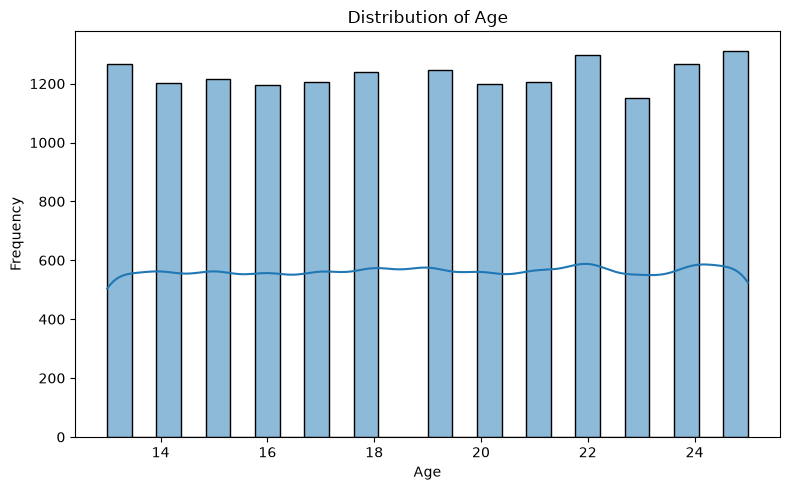

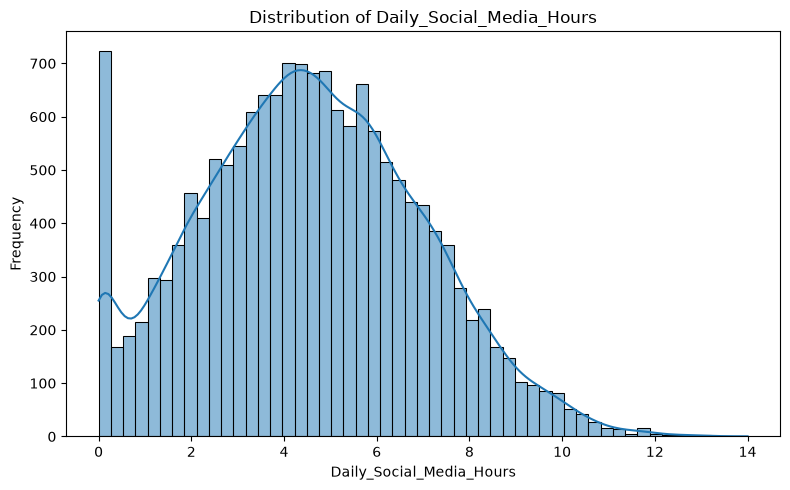

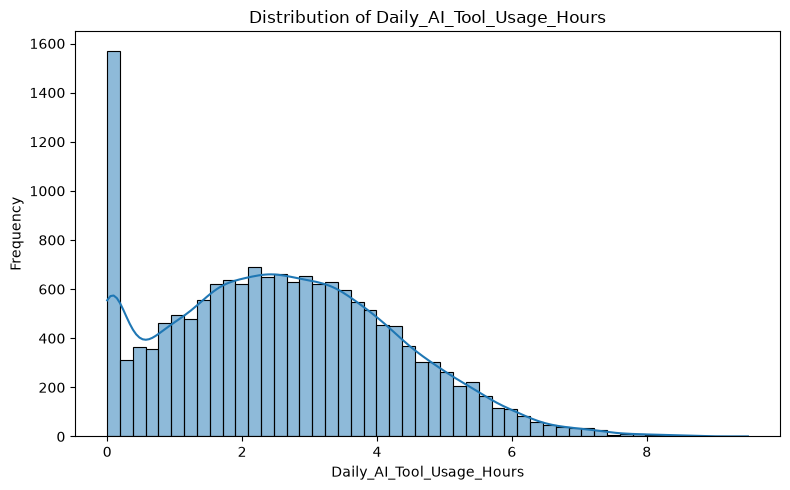

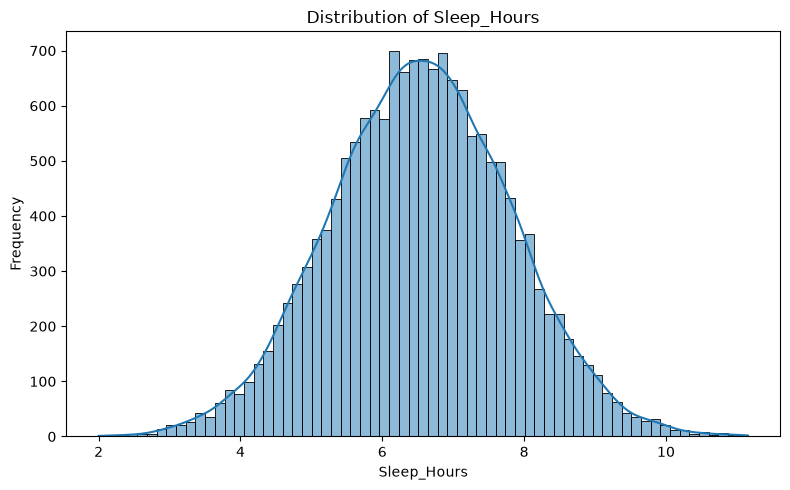

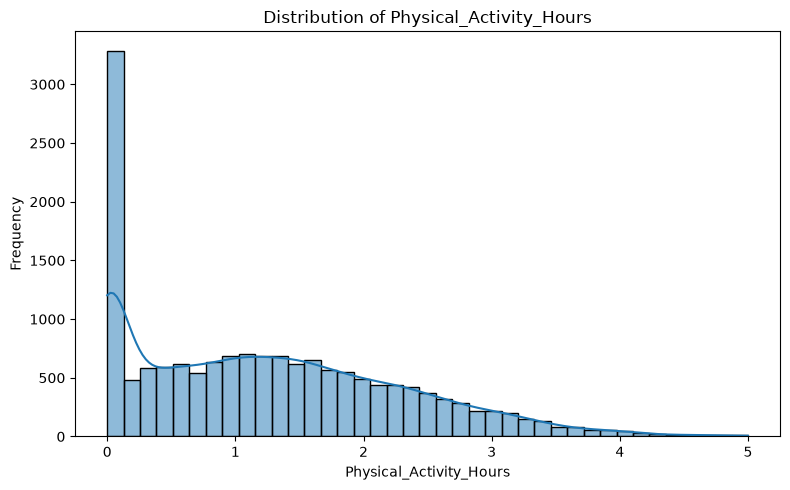

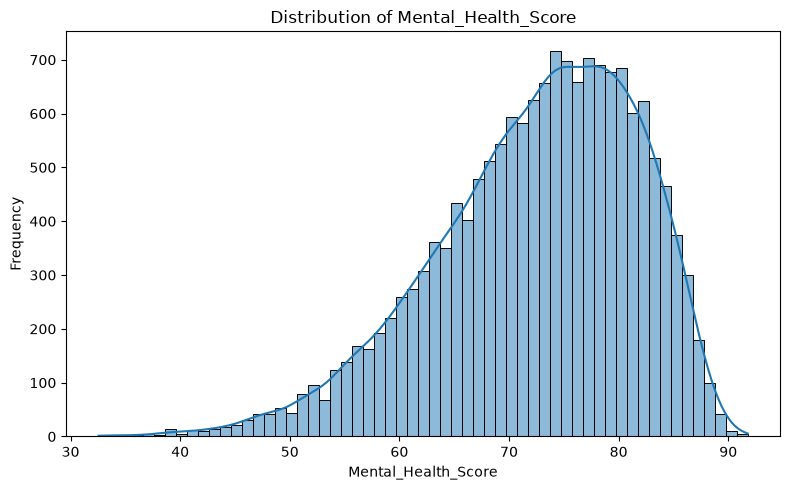

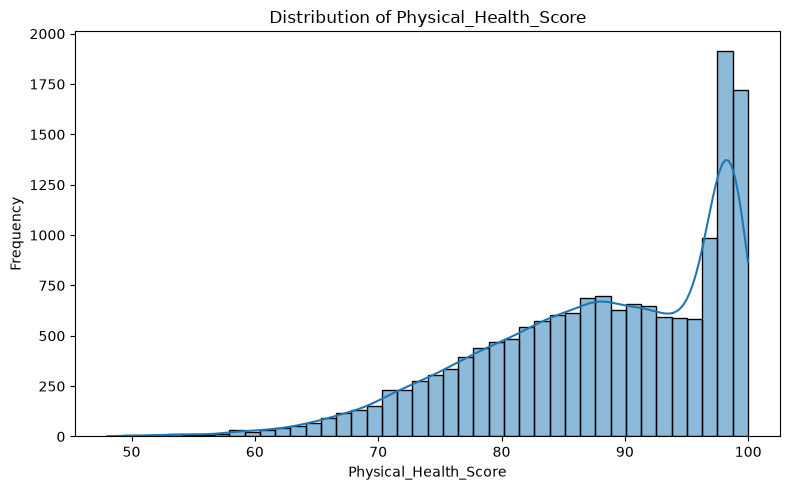

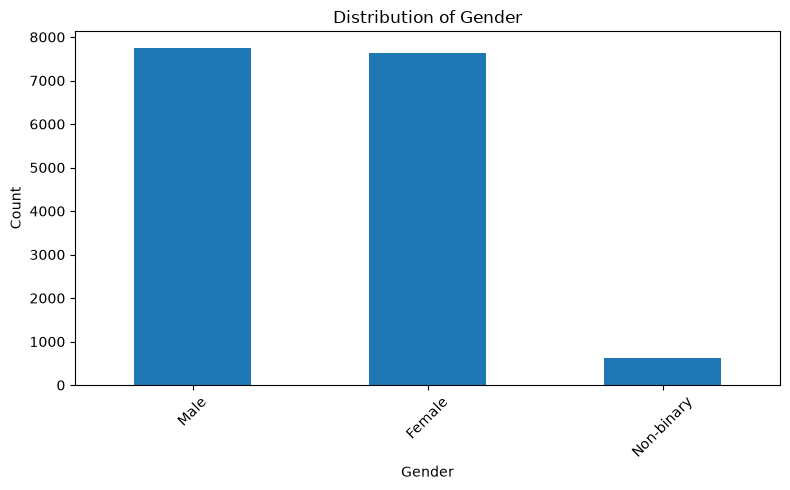

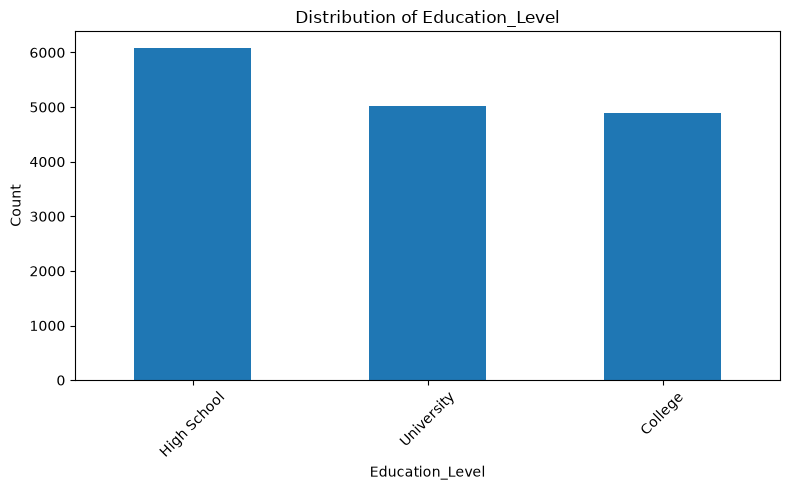

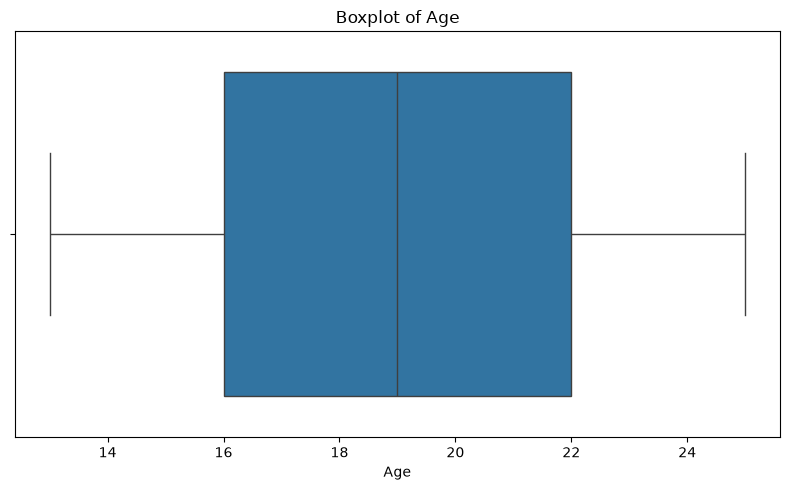

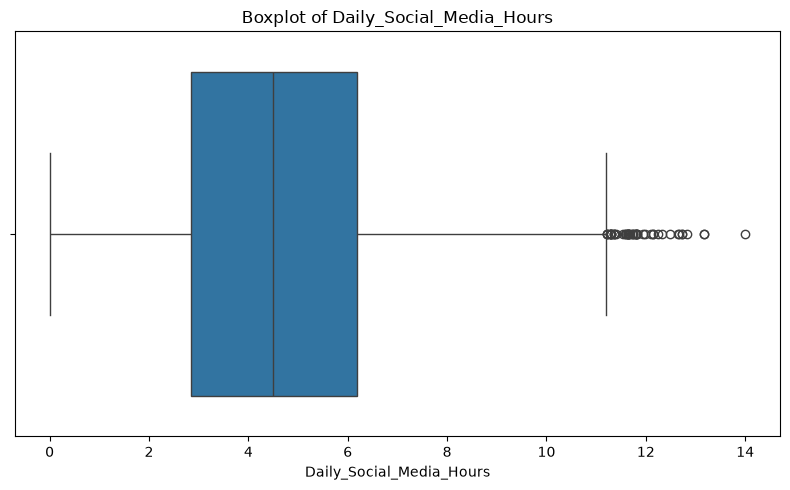

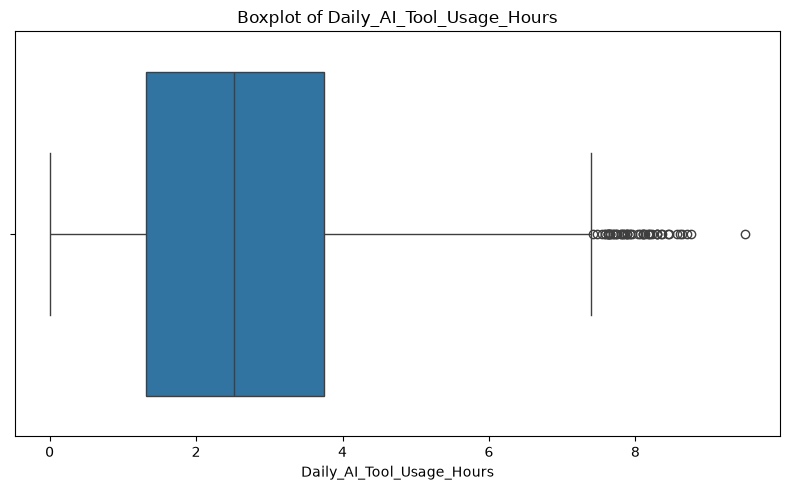

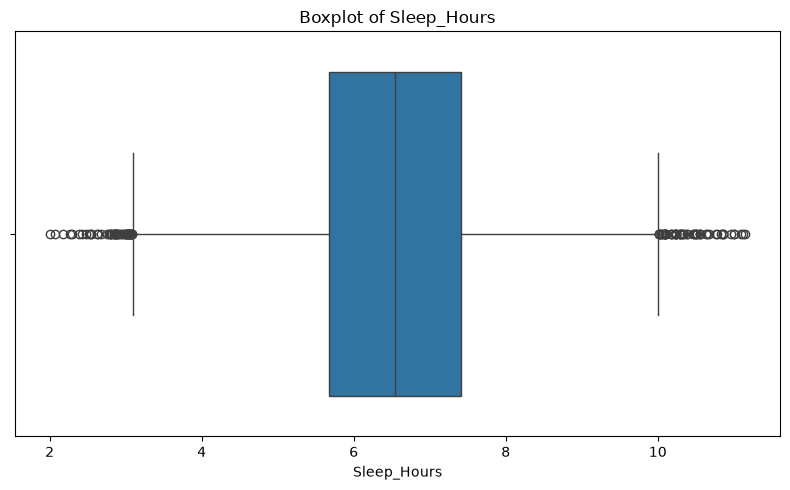

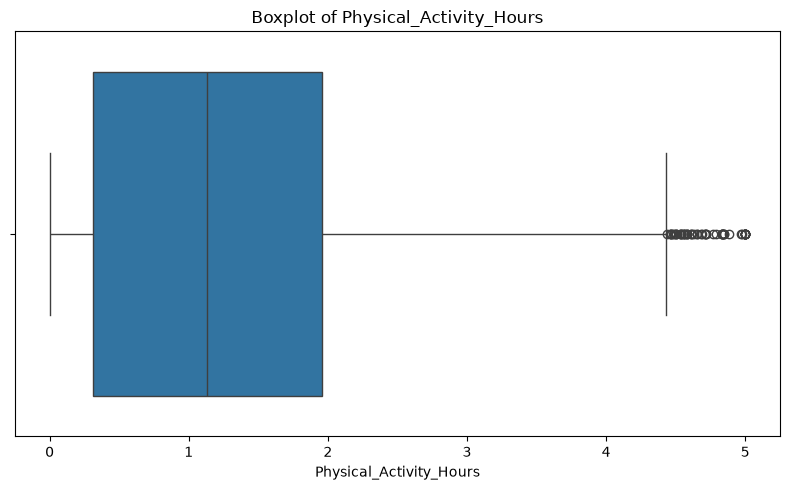

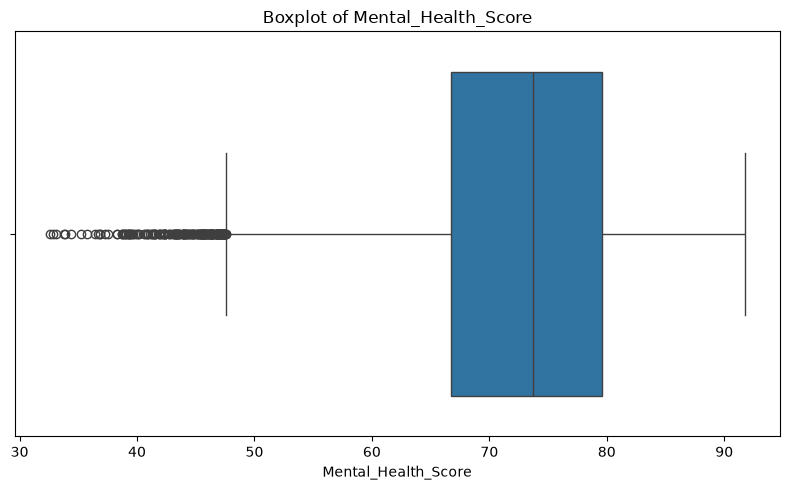

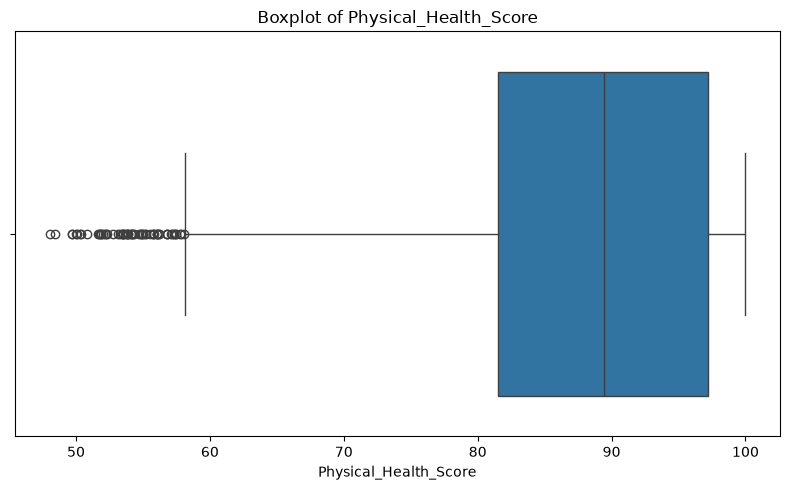

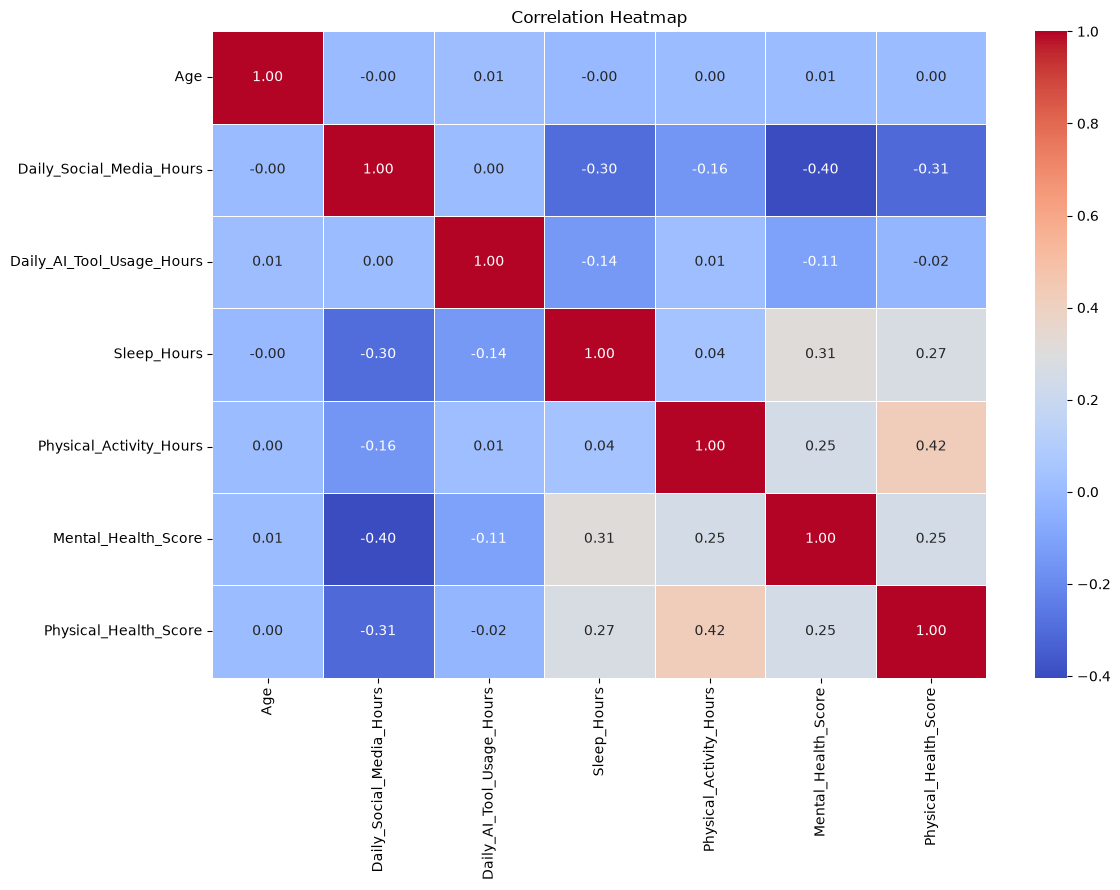

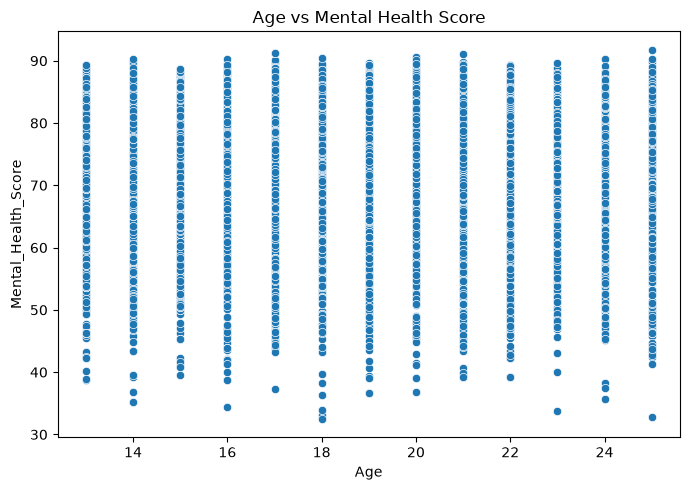

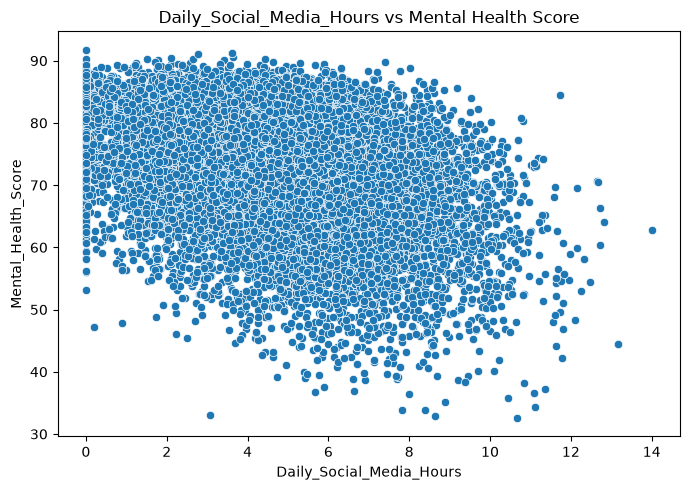

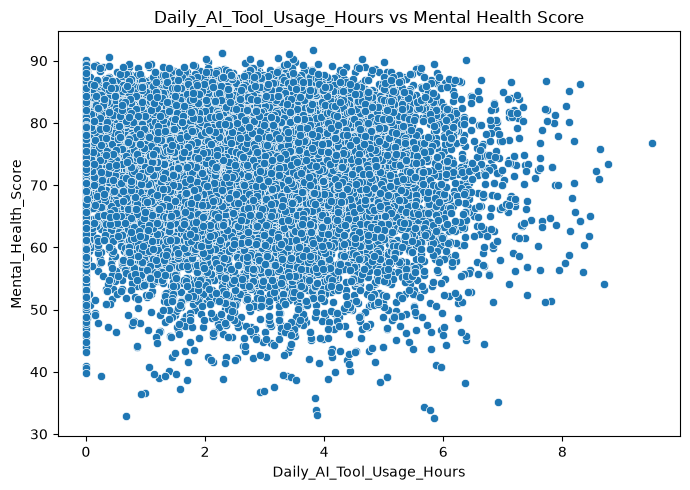

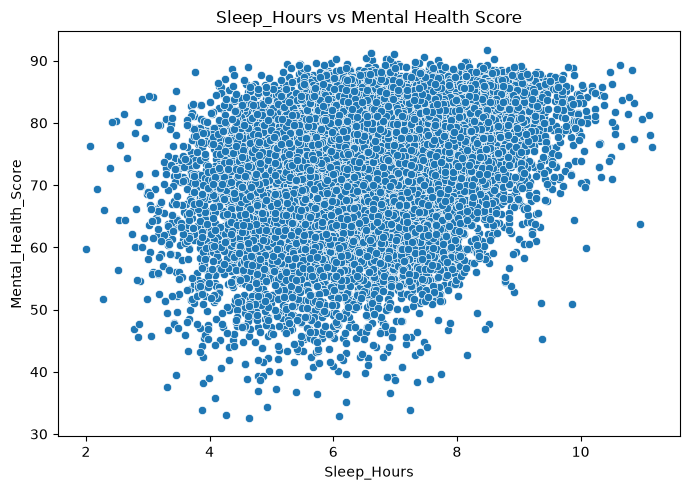

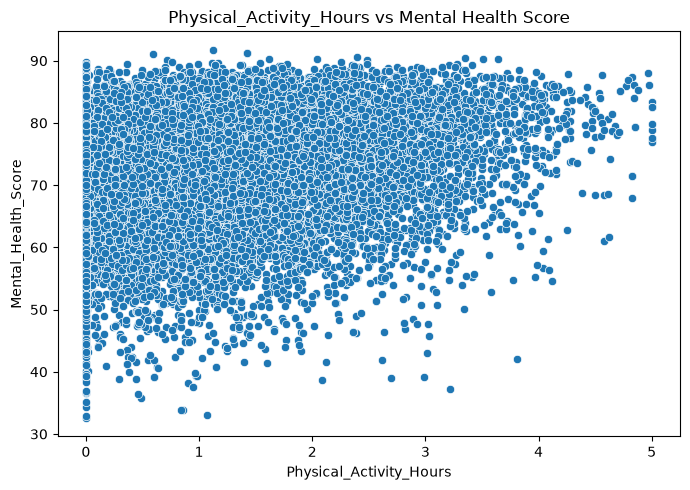

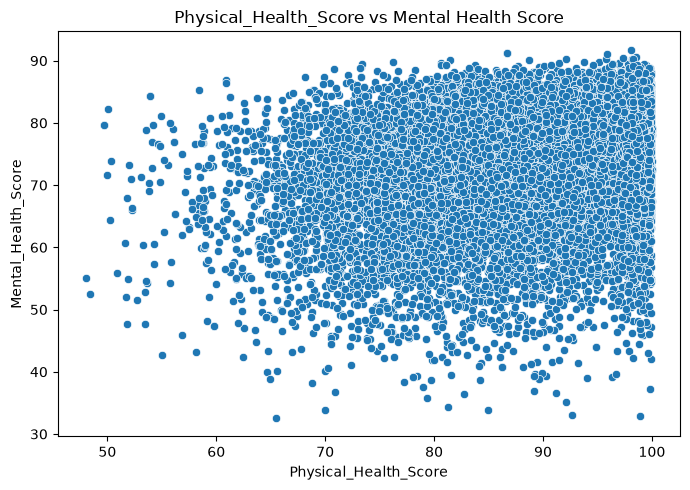

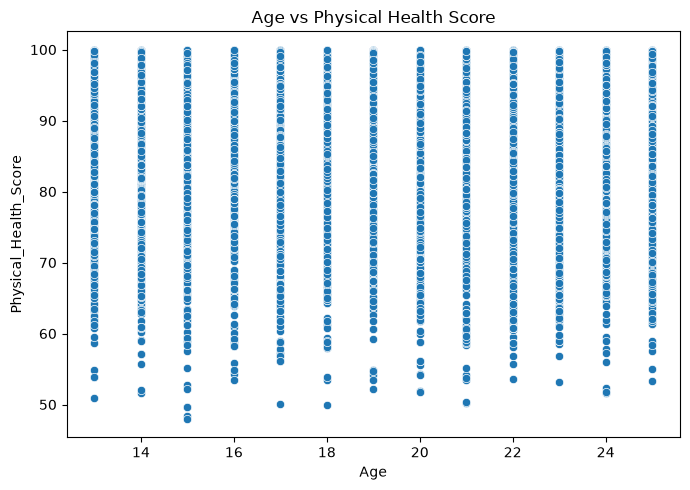

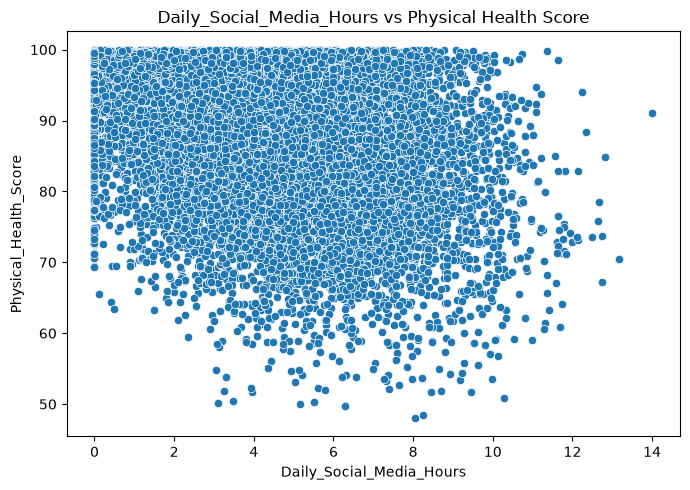

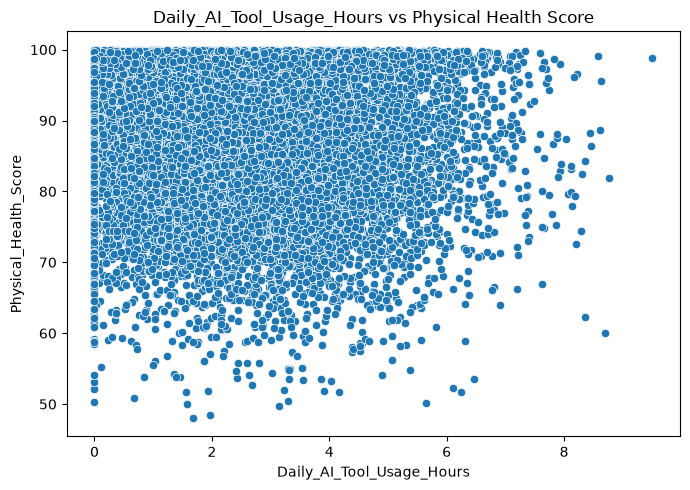

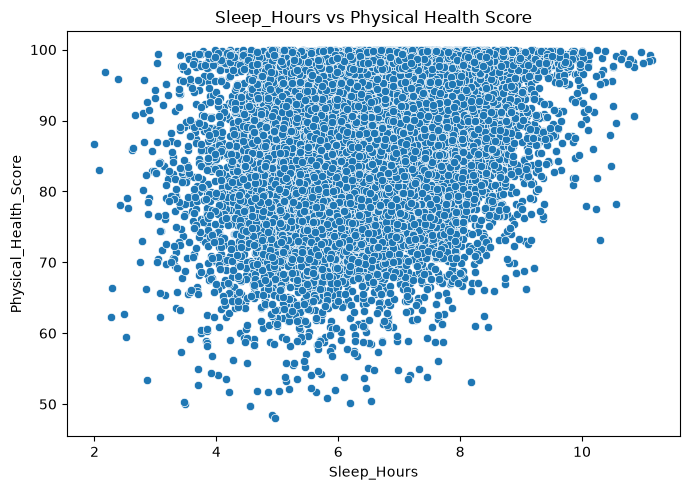

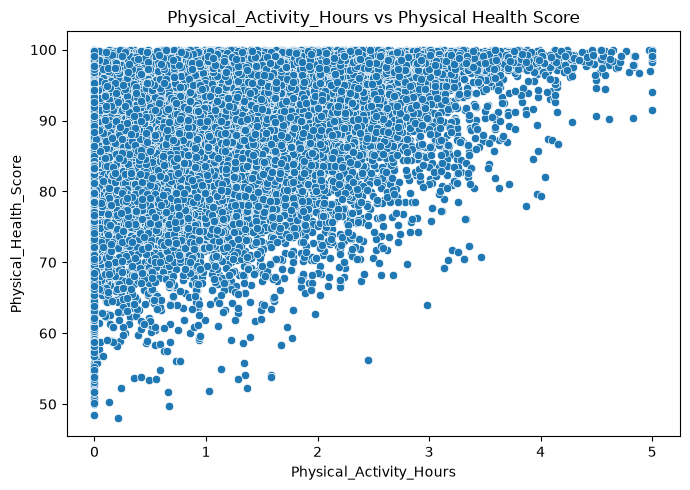

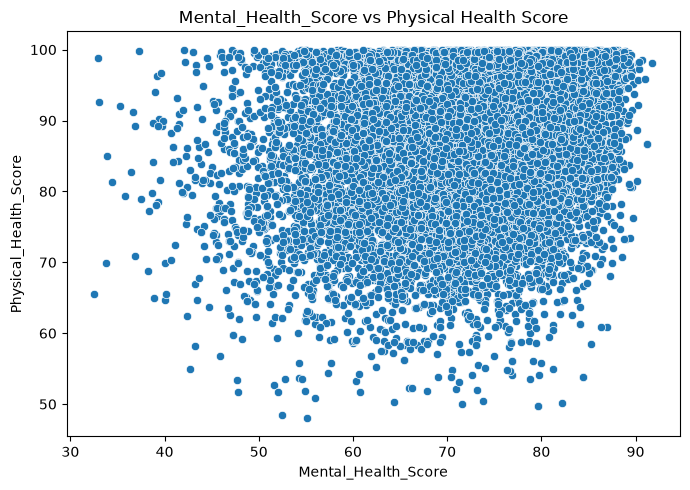

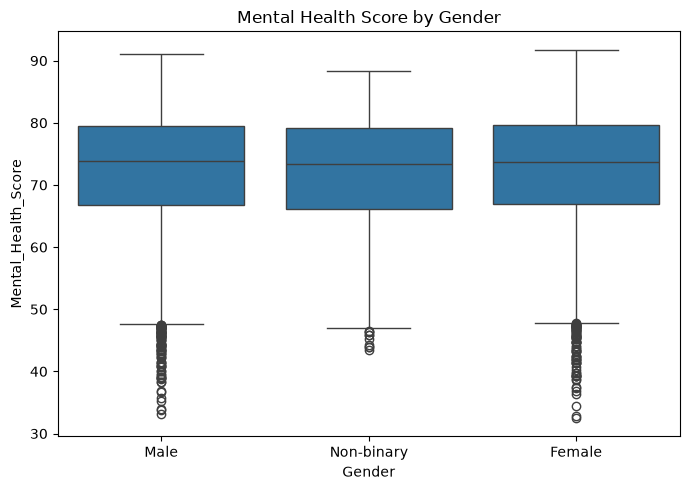

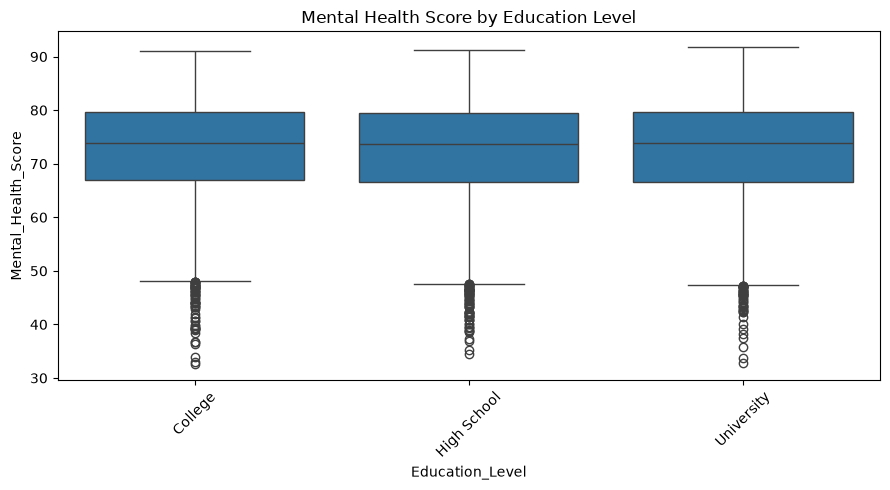

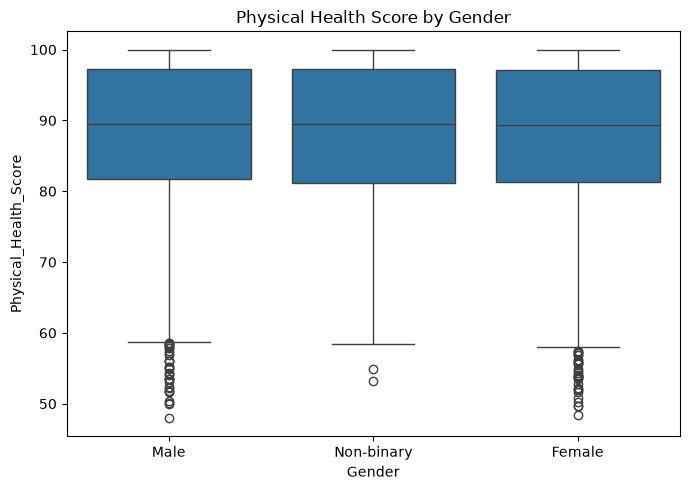

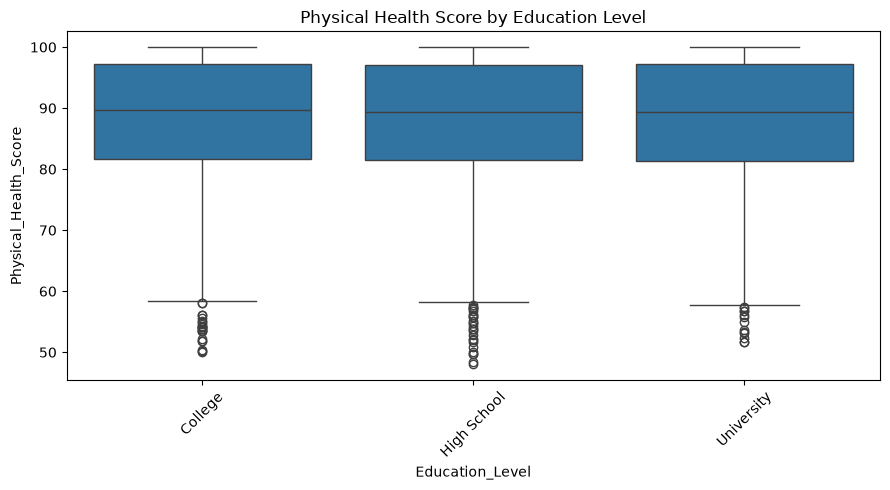

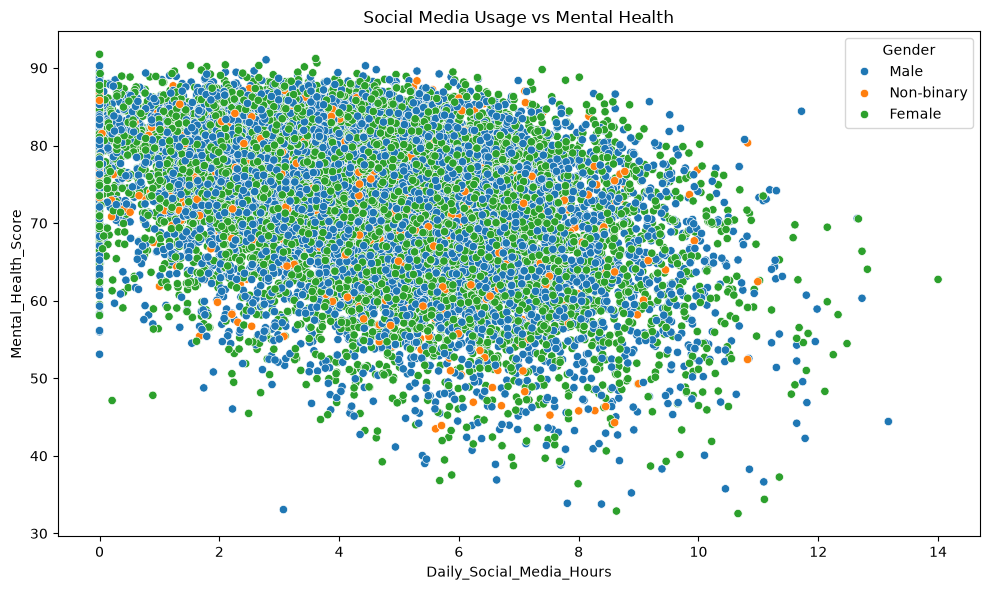

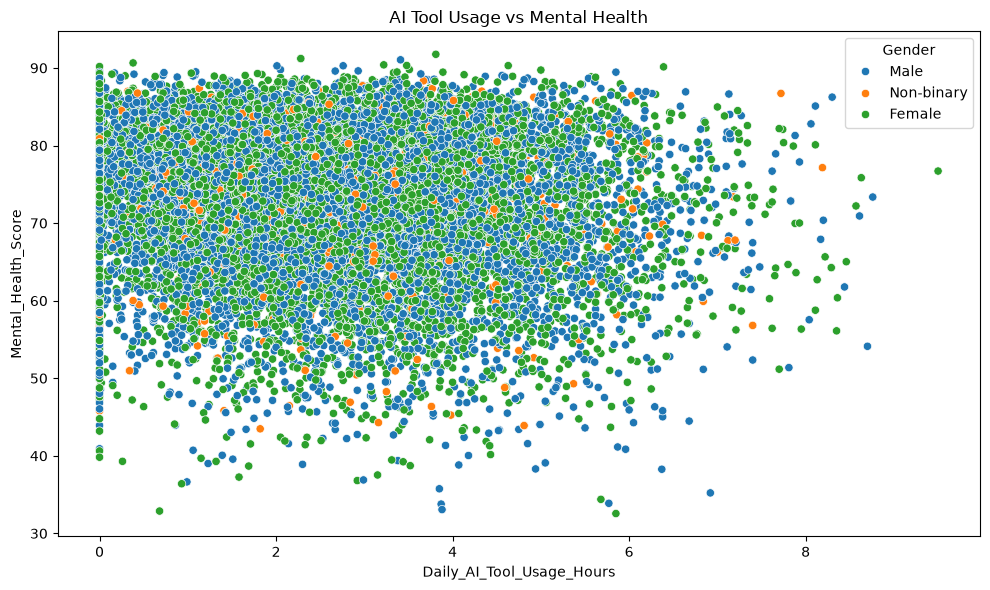

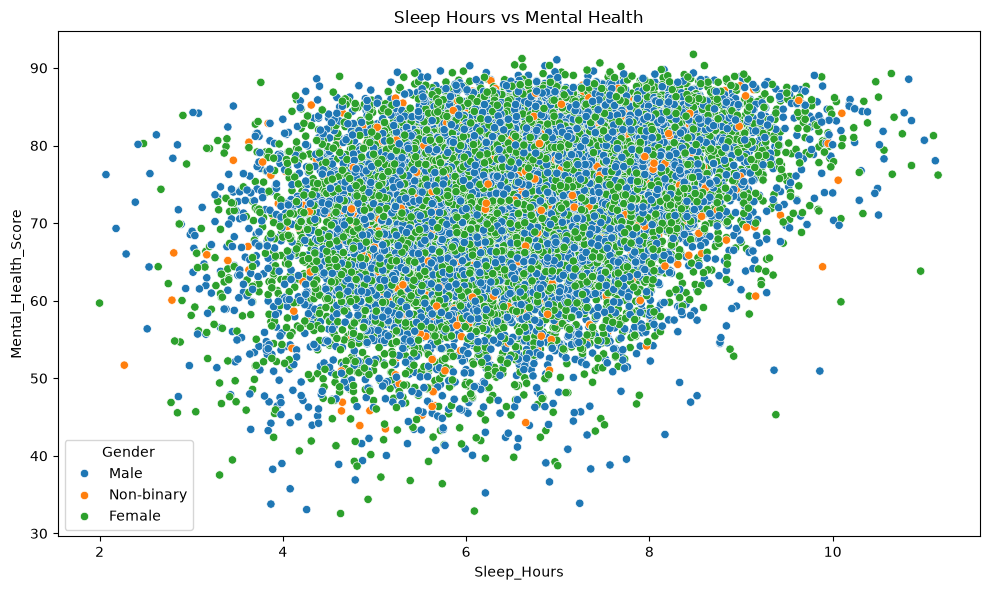

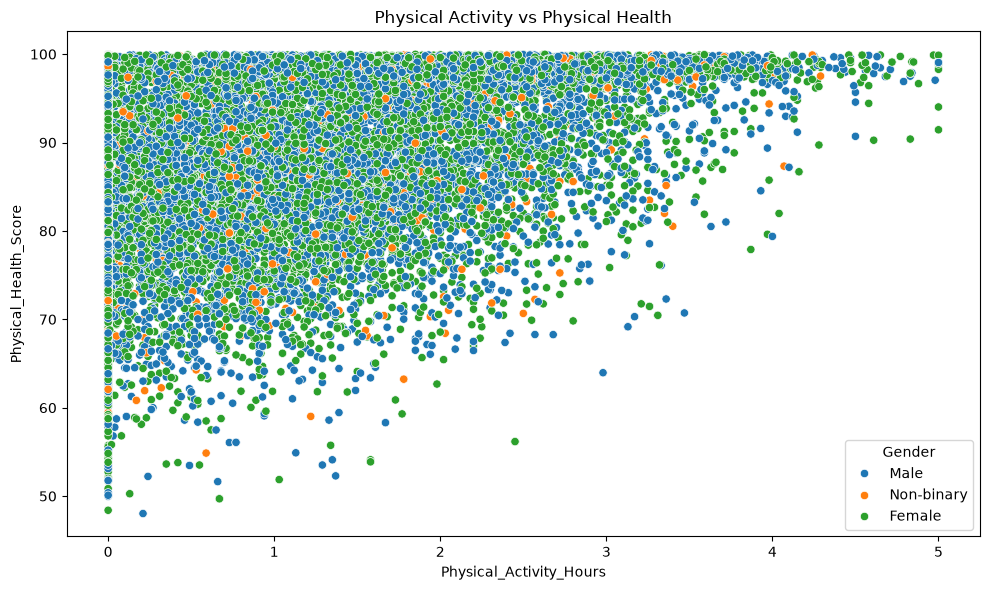


Skewness:


,Skewness
Physical_Activity_Hours,0.618817
Daily_AI_Tool_Usage_Hours,0.338173
Daily_Social_Media_Hours,0.156575
Sleep_Hours,0.014566
Age,-0.011042
Mental_Health_Score,-0.682640
Physical_Health_Score,-0.749444



Strongest Correlations:


Absolute_Correlation
Physical_Activity_Hours   Physical_Health_Score                  0.420732
Daily_Social_Media_Hours  Mental_Health_Score                    0.403584
Sleep_Hours               Mental_Health_Score                    0.312832
Daily_Social_Media_Hours  Physical_Health_Score                  0.308048
                          Sleep_Hours                            0.297566
Sleep_Hours               Physical_Health_Score                  0.269694
Mental_Health_Score       Physical_Health_Score                  0.246062
Physical_Activity_Hours   Mental_Health_Score                    0.245338
Daily_Social_Media_Hours  Physical_Activity_Hours                0.156614
Daily_AI_Tool_Usage_Hours Sleep_Hours                            0.140798
                          Mental_Health_Score                    0.110701
Sleep_Hours               Physical_Activity_Hours                0.042490
Daily_AI_Tool_Usage_Hours Physical_Health_Score                  0.022809
                          Physical_Activity_Hours                0.013161
Age                       Daily_AI_Tool_Usage_Hours              0.012884
                          Mental_Health_Score                    0.005329
                          Sleep_Hours                            0.004898
                          Physical_Activity_Hours                0.003846
                          Physical_Health_Score                  0.003077
Daily_Social_Media_Hours  Daily_AI_Tool_Usage_Hours              0.003032
Age                       Daily_Social_Media_Hours               0.002394
                          Age                                         NaN
Daily_Social_Media_Hours  Age                                         NaN
                          Daily_Social_Media_Hours                    NaN
Daily_AI_Tool_Usage_Hours Age                                         NaN
                          Daily_Social_Media_Hours                    NaN
                          Daily_AI_Tool_Usage_Hours                   NaN
Sleep_Hours               Age                                         NaN
                          Daily_Social_Media_Hours                    NaN
                          Daily_AI_Tool_Usage_Hours                   NaN
                          Sleep_Hours                                 NaN
Physical_Activity_Hours   Age                                         NaN
                          Daily_Social_Media_Hours                    NaN
                          Daily_AI_Tool_Usage_Hours                   NaN
                          Sleep_Hours                                 NaN
                          Physical_Activity_Hours                     NaN
Mental_Health_Score       Age                                         NaN
                          Daily_Social_Media_Hours                    NaN
                          Daily_AI_Tool_Usage_Hours                   NaN
                          Sleep_Hours                                 NaN
                          Physical_Activity_Hours                     NaN
                          Mental_Health_Score                         NaN
Physical_Health_Score     Age                                         NaN
                          Daily_Social_Media_Hours                    NaN
                          Daily_AI_Tool_Usage_Hours                   NaN
                          Sleep_Hours                                 NaN
                          Physical_Activity_Hours                     NaN
                          Mental_Health_Score                         NaN
                          Physical_Health_Score                       NaN

In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    if col != "Student_ID":
        plt.figure(figsize=(8,5))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

corr = df[num_cols].corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

if "Mental_Health_Score" in df.columns:
    for col in num_cols:
        if col != "Mental_Health_Score":
            plt.figure(figsize=(7,5))
            sns.scatterplot(data=df, x=col, y="Mental_Health_Score")
            plt.title(f"{col} vs Mental Health Score")
            plt.tight_layout()
            plt.show()

if "Physical_Health_Score" in df.columns:
    for col in num_cols:
        if col != "Physical_Health_Score":
            plt.figure(figsize=(7,5))
            sns.scatterplot(data=df, x=col, y="Physical_Health_Score")
            plt.title(f"{col} vs Physical Health Score")
            plt.tight_layout()
            plt.show()

if "Gender" in df.columns and "Mental_Health_Score" in df.columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x="Gender", y="Mental_Health_Score")
    plt.title("Mental Health Score by Gender")
    plt.tight_layout()
    plt.show()

if "Education_Level" in df.columns and "Mental_Health_Score" in df.columns:
    plt.figure(figsize=(9,5))
    sns.boxplot(data=df, x="Education_Level", y="Mental_Health_Score")
    plt.title("Mental Health Score by Education Level")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if "Gender" in df.columns and "Physical_Health_Score" in df.columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x="Gender", y="Physical_Health_Score")
    plt.title("Physical Health Score by Gender")
    plt.tight_layout()
    plt.show()

if "Education_Level" in df.columns and "Physical_Health_Score" in df.columns:
    plt.figure(figsize=(9,5))
    sns.boxplot(data=df, x="Education_Level", y="Physical_Health_Score")
    plt.title("Physical Health Score by Education Level")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Daily_Social_Media_Hours",
    y="Mental_Health_Score",
    hue="Gender" if "Gender" in df.columns else None
)
plt.title("Social Media Usage vs Mental Health")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Daily_AI_Tool_Usage_Hours",
    y="Mental_Health_Score",
    hue="Gender" if "Gender" in df.columns else None
)
plt.title("AI Tool Usage vs Mental Health")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Sleep_Hours",
    y="Mental_Health_Score",
    hue="Gender" if "Gender" in df.columns else None
)
plt.title("Sleep Hours vs Mental Health")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Physical_Activity_Hours",
    y="Physical_Health_Score",
    hue="Gender" if "Gender" in df.columns else None
)
plt.title("Physical Activity vs Physical Health")
plt.tight_layout()
plt.show()

print("\nSkewness:")
display(df[num_cols].skew().sort_values(ascending=False).to_frame("Skewness"))

print("\nStrongest Correlations:")
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
display(
    corr_pairs.stack()
    .abs()
    .sort_values(ascending=False)
    .to_frame("Absolute_Correlation")
)